# 01 — Purged walk-forward validation

This notebook reads the saved Phase A1 CSV files. It does **not** retrain models.

Research question: are the current linear order-book signals stable through different parts of the trading day?

In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

current_directory = Path.cwd()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)
reports_directory = project_root / "reports" / "tables"

In [2]:
paths = {
    horizon: reports_directory / f"walk_forward_h{horizon}_folds.csv"
    for horizon in (10, 50, 100)
}

missing = [str(path) for path in paths.values() if not path.exists()]
assert not missing, (
    "Run scripts/run_walk_forward.ps1 first. Missing files:\n"
    + "\n".join(missing)
)

fold_results = pd.concat(
    [
        pd.read_csv(path).assign(horizon=horizon)
        for horizon, path in paths.items()
    ],
    ignore_index=True,
)

summary = pd.read_csv(
    reports_directory / "walk_forward_summary.csv"
)

fold_results.head(), summary

(   horizon  fold  train_start  train_end  validation_start  validation_end  \
 0       10     1            0     120016            120117          160155   
 1       10     2            0     160055            160156          200194   
 2       10     3            0     200094            200195          240233   
 3       10     4            0     240133            240234          280272   
 4       10     5            0     280172            280273          320311   
 
    train_rows  validation_rows  purge_events  development_end_exclusive  ...  \
 0      120017            40039           100                     320312  ...   
 1      160056            40039           100                     320312  ...   
 2      200095            40039           100                     320312  ...   
 3      240134            40039           100                     320312  ...   
 4      280173            40039           100                     320312  ...   
 
    active_signals  active_signal_fr

## 1. Fold structure

Training grows with every fold, while validation always moves later in event time.

In [3]:
fold_structure = fold_results[
    [
        "horizon",
        "fold",
        "train_rows_after_target_filter",
        "validation_rows_after_target_filter",
        "validation_time_start_seconds",
        "validation_time_end_seconds",
    ]
].copy()

fold_structure

,horizon,fold,train_rows_after_target_filter,validation_rows_after_target_filter,validation_time_start_seconds,validation_time_end_seconds
0,10,1,120017,40039,40504.816459,43228.641331
1,10,2,160056,40039,43228.641331,45969.413605
2,10,3,200095,40039,45969.414798,49362.956245
3,10,4,240134,40039,49362.956481,52160.900749
4,10,5,280173,40039,52160.918068,55011.764846
5,50,1,120017,40039,40504.816459,43228.641331
6,50,2,160056,40039,43228.641331,45969.413605
7,50,3,200095,40039,45969.414798,49362.956245
8,50,4,240134,40039,49362.956481,52160.900749
9,50,5,280173,40039,52160.918068,55011.764846


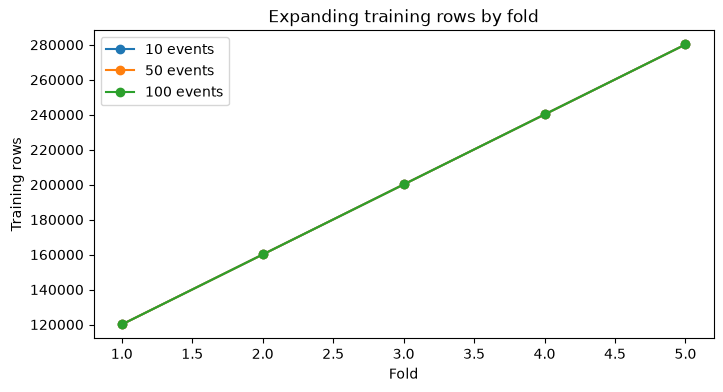

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

for horizon, group in fold_results.groupby("horizon"):
    ax.plot(
        group["fold"],
        group["train_rows_after_target_filter"],
        marker="o",
        label=f"{horizon} events",
    )

ax.set_title("Expanding training rows by fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Training rows")
ax.legend()
plt.show()

## 2. Rank IC stability

A useful horizon should show positive rank IC in most folds, not only one favourable period.

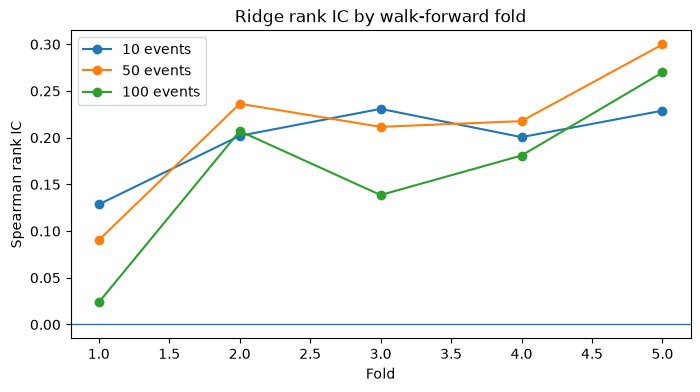

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for horizon, group in fold_results.groupby("horizon"):
    ax.plot(
        group["fold"],
        group["ridge_rank_ic"],
        marker="o",
        label=f"{horizon} events",
    )

ax.axhline(0, linewidth=1)
ax.set_title("Ridge rank IC by walk-forward fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Spearman rank IC")
ax.legend()
plt.show()

## 3. Improvement over the zero-return baseline

Positive values mean Ridge improves on the zero-return predictor.

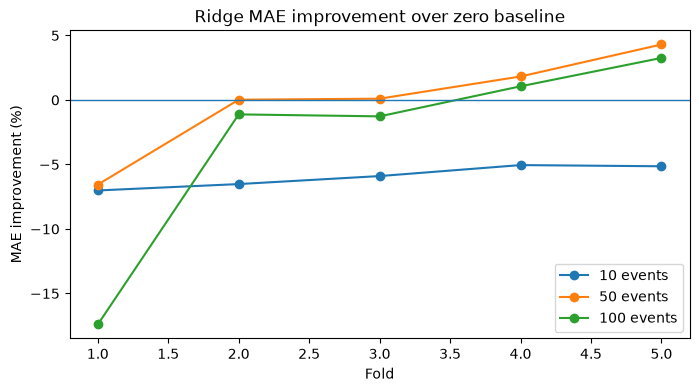

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

for horizon, group in fold_results.groupby("horizon"):
    ax.plot(
        group["fold"],
        group["ridge_mae_improvement_pct"],
        marker="o",
        label=f"{horizon} events",
    )

ax.axhline(0, linewidth=1)
ax.set_title("Ridge MAE improvement over zero baseline")
ax.set_xlabel("Fold")
ax.set_ylabel("MAE improvement (%)")
ax.legend()
plt.show()

## 4. Classification stability

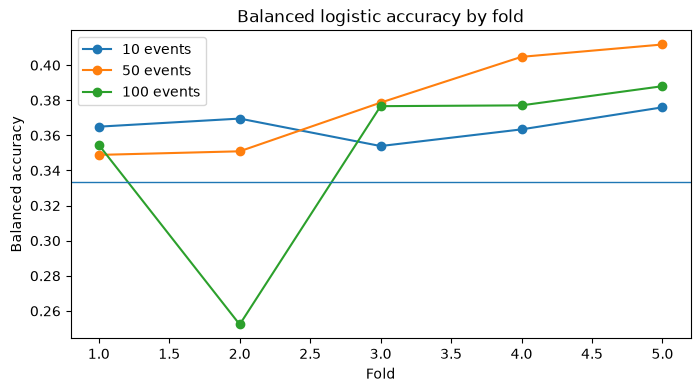

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

for horizon, group in fold_results.groupby("horizon"):
    ax.plot(
        group["fold"],
        group["balanced_accuracy"],
        marker="o",
        label=f"{horizon} events",
    )

ax.axhline(1 / 3, linewidth=1)
ax.set_title("Balanced logistic accuracy by fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Balanced accuracy")
ax.legend()
plt.show()

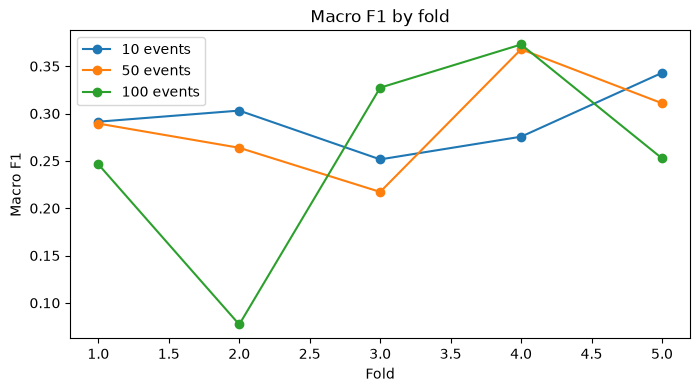

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

for horizon, group in fold_results.groupby("horizon"):
    ax.plot(
        group["fold"],
        group["macro_f1"],
        marker="o",
        label=f"{horizon} events",
    )

ax.set_title("Macro F1 by fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Macro F1")
ax.legend()
plt.show()

## 5. Economic stability

The gross edge should be compared directly with the estimated quoted-spread cost.

In [9]:
economic_means = (
    fold_results.groupby("horizon")[
        [
            "mean_gross_return_active_bps",
            "mean_estimated_cost_active_bps",
            "mean_net_return_active_bps",
        ]
    ]
    .mean()
    .reset_index()
)

economic_means

,horizon,mean_gross_return_active_bps,mean_estimated_cost_active_bps,mean_net_return_active_bps
0,10,0.087062,2.438439,-2.351522
1,50,0.213715,2.566982,-2.353640
2,100,0.252229,2.524530,-2.271547


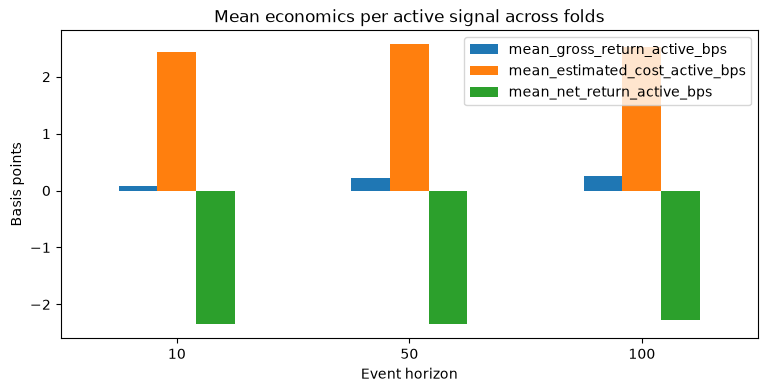

In [10]:
plot_frame = economic_means.set_index("horizon")[
    [
        "mean_gross_return_active_bps",
        "mean_estimated_cost_active_bps",
        "mean_net_return_active_bps",
    ]
]

ax = plot_frame.plot(kind="bar", figsize=(9, 4))
ax.set_title("Mean economics per active signal across folds")
ax.set_xlabel("Event horizon")
ax.set_ylabel("Basis points")
plt.xticks(rotation=0)
plt.show()

## 6. Break-even cost fraction

A value of 0.20 means the gross signal could support only 20% of the modelled quoted-spread cost.

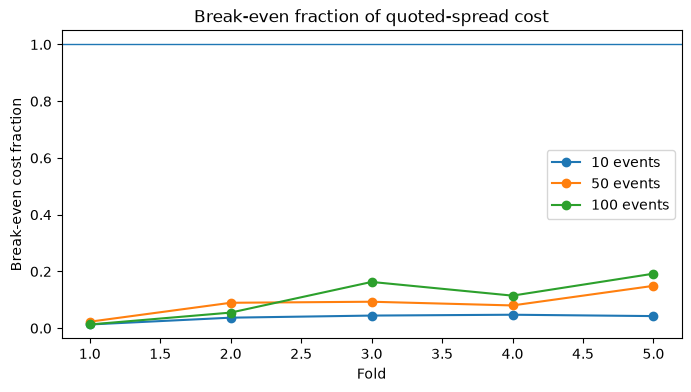

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

for horizon, group in fold_results.groupby("horizon"):
    ax.plot(
        group["fold"],
        group["break_even_cost_fraction"],
        marker="o",
        label=f"{horizon} events",
    )

ax.axhline(1.0, linewidth=1)
ax.set_title("Break-even fraction of quoted-spread cost")
ax.set_xlabel("Fold")
ax.set_ylabel("Break-even cost fraction")
ax.legend()
plt.show()

## 7. Compact horizon comparison

In [12]:
comparison_columns = [
    "horizon",
    "ridge_rank_ic_mean",
    "ridge_rank_ic_std",
    "ridge_rank_ic_positive_folds",
    "ridge_mae_improvement_pct_mean",
    "ridge_mae_improvement_pct_positive_folds",
    "balanced_accuracy_mean",
    "macro_f1_mean",
    "ridge_nonzero_directional_accuracy_mean",
    "mean_gross_return_active_bps_mean",
    "mean_estimated_cost_active_bps_mean",
    "mean_net_return_active_bps_mean",
    "break_even_cost_fraction_mean",
]

summary[[column for column in comparison_columns if column in summary.columns]]

,horizon,ridge_rank_ic_mean,ridge_rank_ic_std,ridge_rank_ic_positive_folds,ridge_mae_improvement_pct_mean,ridge_mae_improvement_pct_positive_folds,balanced_accuracy_mean,macro_f1_mean,ridge_nonzero_directional_accuracy_mean,mean_gross_return_active_bps_mean,mean_estimated_cost_active_bps_mean,mean_net_return_active_bps_mean,break_even_cost_fraction_mean
0,10,0.198175,0.041472,5,-5.925138,0,0.365568,0.292905,0.601221,0.087062,2.438439,-2.351522,0.036914
1,50,0.211135,0.076061,5,-0.064534,4,0.378998,0.289831,0.570636,0.213715,2.566982,-2.353640,0.087019
2,100,0.164012,0.091732,5,-3.095868,2,0.349722,0.255289,0.540337,0.252229,2.524530,-2.271547,0.107587


## Interpretation checklist

Record evidence, not only the best mean:

1. Which horizon has positive rank IC in the most folds?
2. Does Ridge beat the zero-return MAE in most folds?
3. Which horizon has the lowest variability?
4. Does balanced accuracy remain above one-third?
5. Is gross edge positive in most folds?
6. How much of quoted-spread cost can the signal support?
7. Which fold or time period is the principal failure mode?